# V2 — train with the correct sales history

Sales history is keyed by **store, product family, and calendar date**. Transactions are keyed by store and calendar date. Training and API requests both use `src.features.build_features`.

This notebook fits linear regression, random forest, XGBoost, and a tuned XGBoost model. It saves the tuned pipeline only after checking it on an untouched test period.

**Evaluation:** rolling one-day-ahead forecasts. Yesterday's actual sales/transactions are assumed available each day. This is not a fixed-origin 28-day forecast. Missing calendar days stay missing, not zero. Oil uses only prices dated before the forecast; holidays and promotions are assumed known ahead of time.

The historical example requests are diagnostics, not independent accuracy estimates, because they may fall inside the training period. Use the final test-period metrics to judge accuracy.

**Executed results:** trained on a seeded 300,000-row sample. The selected XGBoost achieved test MAE **64.94**, versus **86.93** for last week's sales, across **49,896 rows (2017-07-19 through 2017-08-15)**. Selection used validation MAE; the seven-day mean baseline has slightly better test RMSLE (0.450 versus 0.460), so this model is not best on every metric. The grocery diagnostic predicts **4,321.24** against **4,078** actual; the first-day baby-care diagnostic predicts **17.08** against **0**, with no prior history available. The pipeline was saved and reloaded successfully.


### 1. Setup and resource limits

In [1]:
from pathlib import Path
import sys
import gc
import json
import shutil
import hashlib
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn
import xgboost
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
from xgboost import XGBRegressor

project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "features.py").exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from app.core.config import DATASET_DIR, MODEL_PATH
from src.features import build_features
from src.preprocessor import create_preprocessor
from app.schemas.forecast import ForecastRequest
from app.services.forecasting import build_forecast_features

SEED = 42
N_JOBS = 2
MAX_TRAIN_ROWS = 300_000  # None uses all training rows; needs more RAM/time.
SEARCH_ITERATIONS = 15
HOLDOUT_DAYS = 28
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Dataset directory:", DATASET_DIR)
print("Model destination:", MODEL_PATH)

Dataset directory: /home/s1h/Projects/ML/demandpulse/datasets
Model destination: /home/s1h/Projects/ML/demandpulse/artifacts/V2_models/xgb_best_v2.joblib


### 2. Load and validate source data
The accidental pasted block in `train.csv` was repaired; the original is backed up in `artifacts/train.csv.before-repair.bak`. No malformed rows are silently skipped.

In [2]:
train = pd.read_csv(DATASET_DIR / "train.csv", parse_dates=["date"],
                    dtype={"store_nbr": "int16", "family": "category",
                           "sales": "float32", "onpromotion": "int16", "id": "int32"})
datasets = {
    "train": train,
    "stores": pd.read_csv(DATASET_DIR / "stores.csv"),
    "transactions": pd.read_csv(DATASET_DIR / "transactions.csv", parse_dates=["date"]),
    "holidays": pd.read_csv(DATASET_DIR / "holidays_events.csv", parse_dates=["date"]),
    "oil": pd.read_csv(DATASET_DIR / "oil.csv", parse_dates=["date"]),
}
assert train["id"].is_unique
assert not train.duplicated(["date", "store_nbr", "family"]).any()
assert train[["date", "store_nbr", "family", "sales", "onpromotion"]].notna().all().all()
assert train["sales"].ge(0).all()
assert train["onpromotion"].ge(0).all()
assert not datasets["transactions"].duplicated(["date", "store_nbr"]).any()
print(f"{len(train):,} sales rows: {train.date.min().date()} to {train.date.max().date()}")

3,000,888 sales rows: 2013-01-01 to 2017-08-15


### 3. Separate dates before sampling
The last 28 days are reserved for testing; the preceding 28 days are validation. Only the earlier training rows are sampled, uniformly with seed 42. All source history is retained for feature lookups.

In [3]:
test_start = train.date.max() - pd.Timedelta(days=HOLDOUT_DAYS - 1)
validation_start = test_start - pd.Timedelta(days=HOLDOUT_DAYS)
training_rows = train.loc[train.date < validation_start]
if MAX_TRAIN_ROWS is not None and len(training_rows) > MAX_TRAIN_ROWS:
    training_rows = training_rows.sample(MAX_TRAIN_ROWS, random_state=SEED)
validation_rows = train.loc[train.date.between(validation_start, test_start, inclusive="left")]
test_rows = train.loc[train.date >= test_start]
training_rows = training_rows.sort_values(["date", "store_nbr", "family"])
assert training_rows.date.max() < validation_rows.date.min()
assert validation_rows.date.max() < test_rows.date.min()
display(pd.DataFrame([
    {"split": name, "rows": len(rows), "first_date": rows.date.min().date(),
     "last_date": rows.date.max().date()}
    for name, rows in [("training", training_rows), ("validation", validation_rows), ("test", test_rows)]
]))

,split,rows,first_date,last_date
0,training,300000,2013-01-01,2017-06-20
1,validation,49896,2017-06-21,2017-07-18
2,test,49896,2017-07-19,2017-08-15


### 4. Build exactly the same features as the API
History lookups always exclude the forecast date. Validation/test features may use actuals from earlier holdout days, matching the rolling daily evaluation described above.

In [4]:
X_train_v2 = build_features(training_rows, datasets)
y_train_v2 = training_rows["sales"].copy()
print("Training features ready:", X_train_v2.shape)
X_val_v2 = build_features(validation_rows, datasets)
y_val_v2 = validation_rows["sales"].copy()
X_test_v2 = build_features(test_rows, datasets)
y_test_v2 = test_rows["sales"].copy()
for X, y in [(X_train_v2, y_train_v2), (X_val_v2, y_val_v2), (X_test_v2, y_test_v2)]:
    assert X.index.equals(y.index)
    assert "sales" not in X and "id" not in X and "date" not in X
assert list(X_train_v2) == list(X_val_v2) == list(X_test_v2)
print("Validation/test shapes:", X_val_v2.shape, X_test_v2.shape)

Training features ready: (300000, 28)


Validation/test shapes: (49896, 28) (49896, 28)


### 5. Verify the reported request and API/training agreement

In [5]:
example_payloads = [
    ForecastRequest(date="2016-08-14", store_nbr=54, family="GROCERY I", onpromotion=42),
    ForecastRequest(date="2013-01-01", store_nbr=1, family="BABY CARE", onpromotion=0),
]
example_rows = pd.DataFrame([p.model_dump() for p in example_payloads])
example_features = build_features(example_rows, datasets)
for i, payload in enumerate(example_payloads):
    serving_features = build_forecast_features(payload, datasets)
    pd.testing.assert_frame_equal(example_features.iloc[[i]].reset_index(drop=True), serving_features)
assert example_features.loc[0, "lag_1"] == 3684
assert example_features.loc[0, "lag_7"] == 4875
assert pd.isna(example_features.loc[1, "lag_1"])
# Check an actual held-out row as well as the reported examples.
sample = test_rows.iloc[0]
payload = ForecastRequest(date=sample.date.date(), store_nbr=int(sample.store_nbr),
                          family=str(sample.family), onpromotion=int(sample.onpromotion))
pd.testing.assert_frame_equal(X_test_v2.iloc[[0]].reset_index(drop=True),
                              build_forecast_features(payload, datasets))
print("Training/API parity passed; correct store/family history confirmed.")
display(example_features[["store_nbr", "family", "lag_1", "lag_7", "rolling_mean_7"]])

Training/API parity passed; correct store/family history confirmed.


,store_nbr,family,lag_1,lag_7,rolling_mean_7
0,54,GROCERY I,3684.0,4875.0,2898.857178
1,1,BABY CARE,NaN,NaN,NaN


### 6. Preprocessing and common evaluation
Store numbers and clusters are categories. Each estimator gets its own fitted preprocessor. All scores use the same nonnegative clipping as the API; no rounding is applied before scoring.

In [6]:
categorical_cols = ["store_nbr", "family", "city", "state", "type", "cluster", "holiday_type"]
numerical_cols = [c for c in X_train_v2 if c not in categorical_cols]
preprocessor = create_preprocessor(numerical_cols, categorical_cols, scale_numeric=True)
tree_preprocessor = create_preprocessor(numerical_cols, categorical_cols)

def metrics(actual, prediction):
    prediction = np.maximum(np.asarray(prediction), 0)
    return {"MAE": float(mean_absolute_error(actual, prediction)),
            "RMSE": float(np.sqrt(mean_squared_error(actual, prediction))),
            "RMSLE": float(np.sqrt(mean_squared_log_error(actual, prediction)))}

validation_scores = {}
# Fall back to zero only when the baseline itself has no available history.
validation_scores["Last week's sales"] = metrics(y_val_v2, X_val_v2.lag_7.fillna(0))
validation_scores["Previous 7-day mean"] = metrics(y_val_v2, X_val_v2.rolling_mean_7.fillna(0))

### 7. Linear regression baseline

In [7]:
linear_regression_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LinearRegression(tol=1e-4)),
])
linear_regression_pipeline.fit(X_train_v2, y_train_v2)
validation_scores["Linear regression"] = metrics(y_val_v2, linear_regression_pipeline.predict(X_val_v2))
print(validation_scores["Linear regression"])

{'MAE': 75.99790979820594, 'RMSE': 259.20901590968145, 'RMSLE': 1.303654119604403}


### 8. Random forest

In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", RandomForestRegressor(
        n_estimators=50, max_depth=12, min_samples_split=10,
        max_features=0.7, bootstrap=True, max_samples=0.2,
        n_jobs=N_JOBS, random_state=SEED,
    )),
])
rf_pipeline.fit(X_train_v2, y_train_v2)
validation_scores["Random forest"] = metrics(y_val_v2, rf_pipeline.predict(X_val_v2))
print(validation_scores["Random forest"])

{'MAE': 60.48855907342099, 'RMSE': 231.6539972738633, 'RMSLE': 0.4388186223981965}


### 9. XGBoost

In [9]:
xgb_pipeline = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", XGBRegressor(
        objective="reg:squarederror", n_estimators=300, learning_rate=0.05,
        max_depth=6, min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0, reg_lambda=1, tree_method="hist", n_jobs=N_JOBS,
        random_state=SEED,
    )),
])
xgb_pipeline.fit(X_train_v2, y_train_v2)
validation_scores["XGBoost"] = metrics(y_val_v2, xgb_pipeline.predict(X_val_v2))
print(validation_scores["XGBoost"])

{'MAE': 59.4644775390625, 'RMSE': 223.50023594786202, 'RMSLE': 0.5035720426619475}


### 10. Tune on the validation dates only
The test period is never passed to the search. `refit=False` avoids automatically fitting the selected model on validation labels. The selected parameters are fitted explicitly on training rows below.

In [10]:
X_search = pd.concat([X_train_v2, X_val_v2], ignore_index=True)
y_search = pd.concat([y_train_v2, y_val_v2], ignore_index=True)
fold = np.concatenate([np.full(len(X_train_v2), -1), np.zeros(len(X_val_v2))]).astype(int)
param_distributions = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 6, 8],
    "model__min_child_weight": [1, 5, 10],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_lambda": [1, 5, 10],
}
# Score with the same nonnegative output convention used by the API.
def negative_mae(estimator, X, y):
    return -mean_absolute_error(y, np.maximum(estimator.predict(X), 0))

search = RandomizedSearchCV(
    estimator=clone(xgb_pipeline), param_distributions=param_distributions,
    n_iter=SEARCH_ITERATIONS, scoring=negative_mae,
    cv=PredefinedSplit(fold), n_jobs=1, verbose=2,
    random_state=SEED, refit=False, error_score="raise",
)
search.fit(X_search, y_search)
print("Best parameters:", search.best_params_)
best_xgb = clone(xgb_pipeline).set_params(**search.best_params_)
best_xgb.fit(X_train_v2, y_train_v2)
validation_scores["Tuned XGBoost"] = metrics(y_val_v2, best_xgb.predict(X_val_v2))
# Include the untuned configuration in selection; search need not beat it.
if validation_scores["XGBoost"]["MAE"] < validation_scores["Tuned XGBoost"]["MAE"]:
    best_xgb = xgb_pipeline
    selected_configuration = "Untuned XGBoost (better validation MAE)"
else:
    selected_configuration = "Tuned XGBoost"
print("Selected:", selected_configuration)
del X_search, y_search, fold
gc.collect()
validation_table = pd.DataFrame(validation_scores).T.sort_values("MAE")
display(validation_table.round(3))

Fitting 1 folds for each of 15 candidates, totalling 15 fits


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=6, model__min_child_weight=5, model__n_estimators=400, model__reg_lambda=5, model__subsample=1.0; total time=   4.7s


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=8, model__min_child_weight=10, model__n_estimators=400, model__reg_lambda=10, model__subsample=0.8; total time=   7.3s


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=4, model__min_child_weight=10, model__n_estimators=400, model__reg_lambda=5, model__subsample=1.0; total time=   3.8s


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__reg_lambda=10, model__subsample=0.7; total time=   2.8s


...

[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=10, model__n_estimators=200, model__reg_lambda=1, model__subsample=1.0; total time=   2.1s


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__reg_lambda=5, model__subsample=0.8; total time=   2.5s


[CV] END model__colsample_bytree=1.0, model__learning_rate=0.05, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__reg_lambda=10, model__subsample=0.7; total time=   2.7s
Best parameters: {'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


Selected: Tuned XGBoost


,MAE,RMSE,RMSLE
Tuned XGBoost,57.712,220.294,0.444
XGBoost,59.464,223.500,0.504
Random forest,60.489,231.654,0.439
Linear regression,75.998,259.209,1.304
Last week's sales,83.291,327.513,0.514
Previous 7-day mean,113.491,416.716,0.459


### 11. Final untouched test period
The saved model uses only training-period labels. These scores measure rolling one-day-ahead performance over the complete final 28-day period.

,MAE,RMSE,RMSLE
Selected XGBoost,64.938,225.079,0.460
Last week's sales,86.927,313.827,0.547
Previous 7-day mean,96.302,326.178,0.450


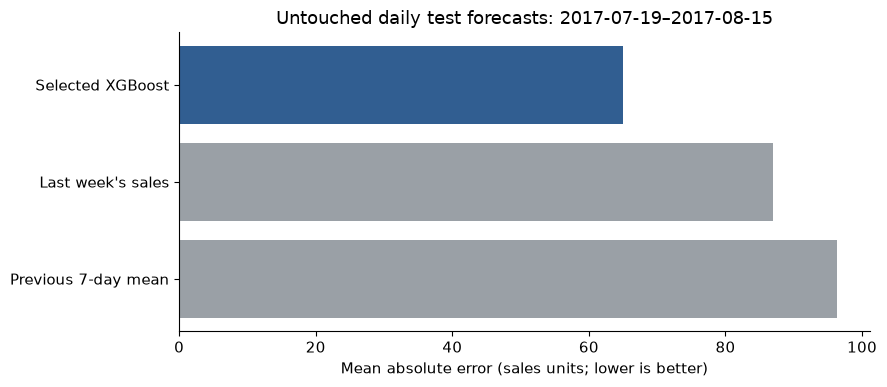

In [11]:
test_predictions = np.maximum(best_xgb.predict(X_test_v2), 0)
test_scores = {
    "Selected XGBoost": metrics(y_test_v2, test_predictions),
    "Last week's sales": metrics(y_test_v2, X_test_v2.lag_7.fillna(0)),
    "Previous 7-day mean": metrics(y_test_v2, X_test_v2.rolling_mean_7.fillna(0)),
}
test_table = pd.DataFrame(test_scores).T
display(test_table.round(3))
assert np.isfinite(test_predictions).all()
assert test_scores["Selected XGBoost"]["MAE"] < test_scores["Last week's sales"]["MAE"],     "Model did not beat last-week baseline; inspect results before replacing the API model."
fig, ax = plt.subplots()
labels = test_table.index.tolist()
ax.barh(labels[::-1], test_table.MAE.to_numpy()[::-1], color=["#9aa0a6", "#9aa0a6", "#315e91"])
ax.set_xlabel("Mean absolute error (sales units; lower is better)")
ax.set_title(f"Untouched daily test forecasts: {test_start.date()}–{train.date.max().date()}")
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig(project_root / "artifacts" / "v2_test_mae.png", dpi=150)
plt.show()

### 12. Historical request diagnostics
These dates precede the holdout; they are **not** independent test cases. Predictions need not exactly equal historical sales, especially with no earlier history.

In [12]:
example_predictions = np.maximum(best_xgb.predict(example_features), 0)
examples = []
for payload, prediction in zip(example_payloads, example_predictions):
    actual = train.loc[(train.date == pd.Timestamp(payload.date))
                       & (train.store_nbr == payload.store_nbr)
                       & (train.family == payload.family), "sales"].iloc[0]
    examples.append({**payload.model_dump(mode="json"), "actual_sales": float(actual),
                     "predicted_sales": round(float(prediction), 2)})
display(pd.DataFrame(examples))

,date,store_nbr,family,onpromotion,actual_sales,predicted_sales
0,2016-08-14,54,GROCERY I,42,4078.0,4321.24
1,2013-01-01,1,BABY CARE,0,0.0,17.08


### 13. Save and reload the model
The previous artifact is backed up once. The API loads this same path at startup; restart the running server after this cell completes.

In [13]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
backup_path = MODEL_PATH.with_name(MODEL_PATH.stem + ".before-history-fix.joblib")
if MODEL_PATH.exists() and not backup_path.exists():
    shutil.copy2(MODEL_PATH, backup_path)
temporary_path = MODEL_PATH.with_suffix(".tmp.joblib")
joblib.dump(best_xgb, temporary_path)
model = joblib.load(temporary_path)
np.testing.assert_allclose(model.predict(example_features), best_xgb.predict(example_features))
temporary_path.replace(MODEL_PATH)

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

report = {
    "evaluation": "rolling one-day-ahead; prior actuals available daily",
    "training_rows": len(X_train_v2), "training_rows_available": int((train.date < validation_start).sum()),
    "validation_rows": len(X_val_v2), "test_rows": len(X_test_v2),
    "validation_start": str(validation_start.date()), "test_start": str(test_start.date()),
    "test_end": str(train.date.max().date()), "seed": SEED,
    "selection": selected_configuration, "search_best_params": search.best_params_,
    "validation_metrics": validation_scores, "test_metrics": test_scores,
    "historical_examples_not_holdout": examples, "feature_columns": list(X_train_v2),
    "source_sha256": {name: sha256_file(DATASET_DIR / name) for name in
        ["train.csv", "stores.csv", "transactions.csv", "holidays_events.csv", "oil.csv"]},
    "feature_code_sha256": {name: sha256_file(project_root / "src" / name)
                            for name in ["features.py", "history.py", "lag_and_rolling.py"]},
    "versions": {"python": platform.python_version(), "pandas": pd.__version__,
                 "sklearn": sklearn.__version__, "xgboost": xgboost.__version__},
}
report_path = MODEL_PATH.with_suffix(".metrics.json")
report_path.write_text(json.dumps(report, indent=2))
print("Saved and reloaded:", MODEL_PATH)
print("Evaluation record:", report_path)

Saved and reloaded: /home/s1h/Projects/ML/demandpulse/artifacts/V2_models/xgb_best_v2.joblib
Evaluation record: /home/s1h/Projects/ML/demandpulse/artifacts/V2_models/xgb_best_v2.metrics.json
